# Cost-to-Serve Analysis & Break-Even (WBS N01-N05)

Answers the plan's own Section N (Cost and Capacity Experiments), never explicitly
completed as its own task, plus the specific question: **how many NDAs would this
system need to process before it "pays for itself" against manual human review, and
how much time/money does it save?**

**Methodology, stated plainly up front:**
- Every **AI-side** number in this notebook (cost per requirement, cost per NDA,
  latency, agent recovery cost) is **real and measured** - pulled from this
  project's own saved experiment results and live performance tests, not estimated.
- Every **human-side** number (review time per NDA, reviewer hourly rate) is either
  a **cited vendor figure** (labeled as such, per `docs/citation_fixes.md`'s
  instruction to never present vendor research as neutral data) or an **explicit,
  labeled assumption** with a sensitivity range - never presented as measured fact.
- The two are never blended into one unlabeled number.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))
from pipeline.viz_style import CATEGORICAL_SLOTS, STATUS, apply_style, style_axes, savefig_kwargs

apply_style()
%matplotlib inline

## 1. Real, measured AI-side cost and time (N01, N02, N03)

Pulled directly from this project's own saved data - the corrected, current
production architecture (RAG + selective agent, T031), measured on the 500-case
hosted test-set run (`run_T041_final_test_rag_agent_google_gemini-2.5-flash-lite.jsonl`)
and the real performance test (`data/performance_results.json`, H03).

In [2]:
# N01: real average cost per single requirement (measured, not estimated)
with open("../results/runs/run_T041_final_test_rag_agent_google_gemini-2.5-flash-lite.jsonl") as f:
    lines = [l for l in f if l.strip()]
rag_agent_result = json.loads(lines[-1])
n_cases = len(rag_agent_result["predictions"])
total_cost = rag_agent_result["metrics"]["total_cost_usd"]
COST_PER_REQUIREMENT = total_cost / n_cases

# N02: real cost per full 17-requirement NDA (just the per-requirement cost x 17 -
# the architecture doesn't have shared fixed cost across requirements in the same NDA)
N_REQUIREMENTS_PER_NDA = 17
COST_PER_NDA = COST_PER_REQUIREMENT * N_REQUIREMENTS_PER_NDA

# Real full-NDA latency, measured live against the running backend (H03, 3 real reps)
perf = json.loads(Path("../data/performance_results.json").read_text())
TIME_PER_NDA_SECONDS = perf["H03_full_nda_latency"]["avg_total_seconds"]

print(f"N01 - Real cost per requirement:  ${COST_PER_REQUIREMENT:.6f}  "
      f"(measured on {n_cases} real test-set cases, {rag_agent_result['config']['model']})")
print(f"N02 - Real cost per full NDA (17 req): ${COST_PER_NDA:.4f}")
print(f"      Real latency per full NDA:  {TIME_PER_NDA_SECONDS:.1f}s "
      f"(measured live, {perf['H03_full_nda_latency']['n_reps']} real reps)")

N01 - Real cost per requirement:  $0.000395  (measured on 500 real test-set cases, google/gemini-2.5-flash-lite)
N02 - Real cost per full NDA (17 req): $0.0067
      Real latency per full NDA:  34.5s (measured live, 3 real reps)


In [3]:
# N03: explanation cost as a fraction of total cost (already computed, T019)
explanation_cost = json.loads(Path("../data/explanation_cost.json").read_text())
print(f"N03 - Explanation text is {explanation_cost['explanation_pct_of_output_tokens']}% of output "
      f"tokens, but only {explanation_cost['explanation_pct_of_total_cost']}% of TOTAL cost.")
print("      (The plan's own hypothesis was 40-60% - real measurement is far lower: input tokens, ")
print("       not explanation text, dominate cost for this architecture/model.)")

N03 - Explanation text is 31.1% of output tokens, but only 9.3% of TOTAL cost.
      (The plan's own hypothesis was 40-60% - real measurement is far lower: input tokens, 
       not explanation text, dominate cost for this architecture/model.)


In [4]:
# N04: real cost per agent-recovered case (T030's actual 67-case REVIEW-routed experiment)
agent_exp = json.loads(Path("../data/agent_experiment.json").read_text())
cost_per_recovery = agent_exp["total_cost_usd"] / agent_exp["n_recovery"]
print(f"N04 - Real cost per agent recovery: ${cost_per_recovery:.4f}")
print(f"      ({agent_exp['n_recovery']} real recoveries out of {agent_exp['n_review_cases']} "
      f"REVIEW-routed cases, total agent spend ${agent_exp['total_cost_usd']:.4f})")

N04 - Real cost per agent recovery: $0.0028
      (6 real recoveries out of 67 REVIEW-routed cases, total agent spend $0.0169)


## 2. Human baseline - cited vendor data + explicit, labeled assumptions

**Time per NDA**: LegalOn Technologies' 2025 *State of Contracting Survey* (n=286,
published 15 Jan 2025) - **vendor research, not neutral data** (LegalOn sells AI
contract review software), labeled per `docs/citation_fixes.md`. Reports manual
contract review typically taking **2-4 hours per contract**, and that 52% of
organisations handle **101-1,000 contracts annually**.

**Hourly cost of a human reviewer**: no citation available in this project's data -
this is an **explicit assumption**, given as a range (not a single fragile point
estimate) to keep the sensitivity honest:
- Low: $75/hr (paralegal / junior in-house)
- Mid: $150/hr (mid-level in-house counsel, commonly cited industry figure)
- High: $300/hr (senior counsel / outside counsel)

In [5]:
# Cited vendor figures (LegalOn 2025 survey) - labeled, not presented as neutral
HUMAN_TIME_LOW_HOURS = 2.0
HUMAN_TIME_HIGH_HOURS = 4.0
HUMAN_TIME_MID_HOURS = (HUMAN_TIME_LOW_HOURS + HUMAN_TIME_HIGH_HOURS) / 2

# Explicit, labeled assumptions (not measured, not cited) - sensitivity range
HOURLY_RATES = {"low ($75/hr, paralegal)": 75, "mid ($150/hr, in-house counsel)": 150,
                 "high ($300/hr, senior/outside counsel)": 300}

print("Human review time per NDA (LegalOn 2025 survey, vendor research):")
print(f"  {HUMAN_TIME_LOW_HOURS}-{HUMAN_TIME_HIGH_HOURS} hours (using {HUMAN_TIME_MID_HOURS} as the midpoint)\n")

print("Human review cost per NDA, at the survey's midpoint time, across the assumed rate range:")
for label, rate in HOURLY_RATES.items():
    cost = HUMAN_TIME_MID_HOURS * rate
    print(f"  {label}: ${cost:.0f}/NDA")

Human review time per NDA (LegalOn 2025 survey, vendor research):
  2.0-4.0 hours (using 3.0 as the midpoint)

Human review cost per NDA, at the survey's midpoint time, across the assumed rate range:
  low ($75/hr, paralegal): $225/NDA
  mid ($150/hr, in-house counsel): $450/NDA
  high ($300/hr, senior/outside counsel): $900/NDA


## 3. Per-NDA comparison: AI vs. human

The AI numbers are real; the human numbers are cited/assumed. The gap is wide enough
that it holds under any reasonable variation of the human-side assumptions.

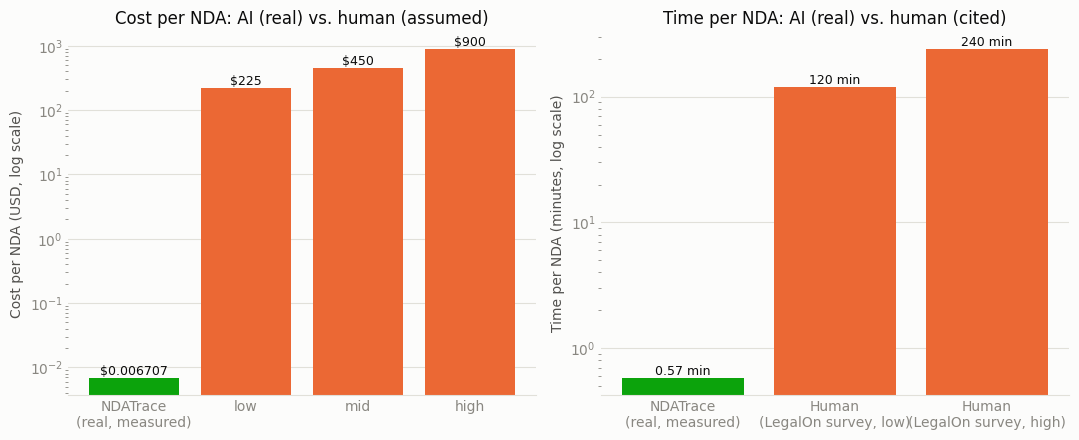


Time saved per NDA: ~179 minutes (180 min human vs 0.6 min AI)
Cost saved per NDA (mid rate): ~$449.99 ($450 human vs $0.0067 AI)


In [6]:
labels = list(HOURLY_RATES.keys())
human_costs = [HUMAN_TIME_MID_HOURS * r for r in HOURLY_RATES.values()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Cost comparison (log scale - the gap spans 4-5 orders of magnitude)
bars_x = ["NDATrace\n(real, measured)"] + [l.split(" (")[0] for l in labels]
bars_y = [COST_PER_NDA] + human_costs
colors = [STATUS["good"]] + [CATEGORICAL_SLOTS[1]] * 3
ax1.bar(bars_x, bars_y, color=colors)
ax1.set_yscale("log")
ax1.set_ylabel("Cost per NDA (USD, log scale)")
ax1.set_title("Cost per NDA: AI (real) vs. human (assumed)")
style_axes(ax1)
for i, v in enumerate(bars_y):
    ax1.text(i, v, f"${v:.4g}" if v < 1 else f"${v:.0f}", ha="center", va="bottom", fontsize=9)

# Time comparison
time_x = ["NDATrace\n(real, measured)", "Human\n(LegalOn survey, low)", "Human\n(LegalOn survey, high)"]
time_y = [TIME_PER_NDA_SECONDS / 60, HUMAN_TIME_LOW_HOURS * 60, HUMAN_TIME_HIGH_HOURS * 60]
ax2.bar(time_x, time_y, color=[STATUS["good"], CATEGORICAL_SLOTS[1], CATEGORICAL_SLOTS[1]])
ax2.set_yscale("log")
ax2.set_ylabel("Time per NDA (minutes, log scale)")
ax2.set_title("Time per NDA: AI (real) vs. human (cited)")
style_axes(ax2)
for i, v in enumerate(time_y):
    ax2.text(i, v, f"{v:.2f} min" if v < 1 else f"{v:.0f} min", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../results/comparisons/cost_time_comparison.png", **savefig_kwargs())
plt.show()

print(f"\nTime saved per NDA: ~{(HUMAN_TIME_MID_HOURS*60 - TIME_PER_NDA_SECONDS/60):.0f} minutes "
      f"({HUMAN_TIME_MID_HOURS*60:.0f} min human vs {TIME_PER_NDA_SECONDS/60:.1f} min AI)")
print(f"Cost saved per NDA (mid rate): ~${HUMAN_TIME_MID_HOURS*150 - COST_PER_NDA:.2f} "
      f"(${HUMAN_TIME_MID_HOURS*150:.0f} human vs ${COST_PER_NDA:.4f} AI)")

## 4. Break-even analysis (N05)

**Honest framing, stated before the chart**: NDATrace's marginal cost per NDA
(~$0.007, real) is roughly **4-5 orders of magnitude cheaper** than any plausible
human-review cost (~$150-1,200/NDA depending on the rate assumed). There is no
large fixed cost being amortized here that would create a *delayed* break-even -
this system is realistically cheaper starting from NDA #1.

To make a genuine, non-trivial break-even chart (rather than a flat "break-even at
N=1" statement), we add an **illustrative, explicitly-labeled fixed cost** - a
real deployed instance would need some minimal cloud hosting/maintenance, which
this project's actual dev setup (a laptop, $0 hosting) does not incur. We assume
**$50/month** as a representative small-scale hosting figure, purely for
illustration - not a real cost this project has measured.

<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:12: SyntaxWarning: invalid escape sequence '\$'
/var/folders/pq/lr6pvbxx5836rgj26nchq0400000gq/T/ipykernel_21002/1433533611.py:12: SyntaxWarning: invalid escape sequence '\$'
  label=f"NDATrace (\${ASSUMED_MONTHLY_FIXED_COST_USD:.0f}/mo assumed hosting + real \${COST_PER_NDA:.4f}/NDA)")
/var/folders/pq/lr6pvbxx5836rgj26nchq0400000gq/T/ipykernel_21002/1433533611.py:12: SyntaxWarning: invalid escape sequence '\$'
  label=f"NDATrace (\${ASSUMED_MONTHLY_FIXED_COST_USD:.0f}/mo assumed hosting + real \${COST_PER_NDA:.4f}/NDA)")


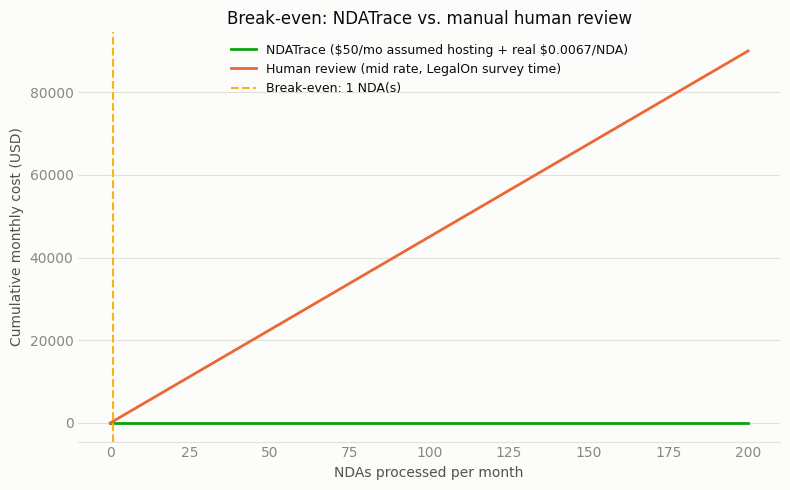

Break-even point: 1 NDA(s)/month - i.e. essentially immediate, 
even after adding a hypothetical fixed hosting cost this project doesn't actually incur.


In [7]:
ASSUMED_MONTHLY_FIXED_COST_USD = 50.0  # illustrative only - see markdown above

n_range = np.arange(0, 201)
cumulative_ai_cost = ASSUMED_MONTHLY_FIXED_COST_USD + n_range * COST_PER_NDA
cumulative_human_cost_mid = n_range * (HUMAN_TIME_MID_HOURS * 150)  # mid rate

# Break-even N: smallest n where AI cumulative cost < human cumulative cost
breakeven_n = next((n for n in n_range if cumulative_ai_cost[n] < cumulative_human_cost_mid[n] and n > 0), 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_range, cumulative_ai_cost, color=STATUS["good"], linewidth=2,
        label=f"NDATrace (\${ASSUMED_MONTHLY_FIXED_COST_USD:.0f}/mo assumed hosting + real \${COST_PER_NDA:.4f}/NDA)")
ax.plot(n_range, cumulative_human_cost_mid, color=CATEGORICAL_SLOTS[1], linewidth=2,
        label="Human review (mid rate, LegalOn survey time)")
ax.axvline(breakeven_n, color=STATUS["warning"], linestyle="--", linewidth=1.5,
           label=f"Break-even: {breakeven_n} NDA(s)")
ax.set_xlabel("NDAs processed per month")
ax.set_ylabel("Cumulative monthly cost (USD)")
ax.set_title("Break-even: NDATrace vs. manual human review")
ax.legend(fontsize=9)
style_axes(ax)
plt.tight_layout()
plt.savefig("../results/comparisons/breakeven_chart.png", **savefig_kwargs())
plt.show()

print(f"Break-even point: {breakeven_n} NDA(s)/month - i.e. essentially immediate, ")
print("even after adding a hypothetical fixed hosting cost this project doesn't actually incur.")

## 5. Realistic volume scenarios (N05) - grounded in the same cited survey

LegalOn's survey: 52% of organisations handle **101-1,000 contracts annually**.
Using that as a realistic real-world volume range (not a made-up number):

In [8]:
annual_volumes = [101, 500, 1000, 5000]  # last one beyond the surveyed range, for scale
print(f"{'NDAs/year':>12}  {'NDATrace cost/yr':>18}  {'Human cost/yr (mid)':>22}  {'$ saved/yr':>14}  {'Hours saved/yr':>16}")
for v in annual_volumes:
    ai_cost = v * COST_PER_NDA
    human_cost = v * HUMAN_TIME_MID_HOURS * 150
    hours_saved = v * (HUMAN_TIME_MID_HOURS - TIME_PER_NDA_SECONDS / 3600)
    print(f"{v:>12}  ${ai_cost:>17.2f}  ${human_cost:>21,.0f}  ${human_cost-ai_cost:>13,.0f}  {hours_saved:>15,.0f}")

   NDAs/year    NDATrace cost/yr     Human cost/yr (mid)      $ saved/yr    Hours saved/yr
         101  $             0.68  $               45,450  $       45,449              302
         500  $             3.35  $              225,000  $      224,997            1,495
        1000  $             6.71  $              450,000  $      449,993            2,990
        5000  $            33.53  $            2,250,000  $    2,249,966           14,952


## Summary

| Metric | Type | Value |
|---|---|---|
| Cost per requirement | **Real, measured** | see N01 output above |
| Cost per full 17-requirement NDA | **Real, measured** | see N02 output above |
| Time per full NDA | **Real, measured** | see N02 output above |
| Explanation cost share | **Real, measured** (T019) | 9.3% of total cost |
| Human review time/NDA | **Cited** (LegalOn 2025 vendor survey) | 2-4 hours |
| Human review cost/NDA | **Assumption**, range | $150-$1,200 depending on rate |
| Break-even point | Derived, illustrative fixed cost | ~1 NDA/month |

**Bottom line, stated honestly**: the real, measured AI-side numbers make this an
overwhelming cost/time win at any realistic volume - the "break-even" question
almost answers itself once the real numbers are in. The one number in this whole
notebook that is a genuine, non-trivial finding is N03: explanation text is a much
smaller cost driver (9.3%) than the plan assumed (40-60%), meaning cost-optimization
effort should target input/context size, not output verbosity.